# A-RoF ARVTDNN-DPD

In [1]:
import sys
from pathlib import Path

file_path    = str(Path.cwd())
project_path = str(Path.cwd().parent)

sys.path.append(project_path)

In [13]:
import pickle 
import numpy as np
import torch as th
import matplotlib.pyplot as plt

from scipy.signal             import welch, firwin, hilbert
from scipy.constants          import pi
from tqdm.notebook            import tqdm
from tabulate                 import tabulate

from optic.comm.ofdm          import modulateOFDM, demodulateOFDM
from optic.comm.modulation    import modulateGray
from optic.models.channels    import linearFiberChannel
from optic.models.devices     import mzm, photodiode
from optic.comm.metrics       import fastBERcalc, calcEVM
from optic.dsp.core           import pnorm, signal_power, finddelay, decimate, upsample, clockSamplingInterp
from optic.dsp.coreGPU        import firFilter
from optic.utils              import parameters, dBm2W

from dpd.nn                   import NN_training
from dpd.utils                import power_amplifier, calcACLR
from dpd.torchUtils           import fitFilterNN

In [3]:
font = {'size':16}
plt.rc('font', **font)
plt.rcParams["font.family"] = "serif"

### 1 - Importação do sinal Tx

In [9]:
symbTx    = np.loadtxt(file_path + r"\transmittedSignal\symbTx.txt", dtype = np.complex64)
symbRx    = np.loadtxt(file_path + r"\transmittedSignal\symbRx.txt", dtype = np.complex64)
sigTx_ref = np.loadtxt(file_path + r"\transmittedSignal\sigTx.txt", dtype = np.complex64)
sigRx_PA  = np.loadtxt(file_path + r"\transmittedSignal\sigRx_PA.txt", dtype = np.complex64)

In [5]:
with open(file_path + r'\transmittedSignal\paramOFDM.pkl', 'rb') as f:
    paramOFDM = pickle.load(f)
    f.close()

with open(file_path + r'\transmittedSignal\paramRF.pkl', 'rb') as f:
    paramRF = pickle.load(f)
    f.close()

with open(file_path + r'\transmittedSignal\paramMZM.pkl', 'rb') as f:
    paramMZM = pickle.load(f)
    f.close()

with open(file_path + r'\transmittedSignal\paramChannel.pkl', 'rb') as f:
    paramChannel = pickle.load(f)
    f.close()

with open(file_path + r'\transmittedSignal\paramPD.pkl', 'rb') as f:
    paramPD = pickle.load(f)
    f.close()

### 2 Identificação do canal

In [15]:
SpS_DPD = 4
SpS = paramOFDM.SpS
Rs  = paramOFDM.Rs
Fs  = paramOFDM.Fs
gain_pre_MZM, gain_pre_PA = paramOFDM.gain_pre_MZM_PA

device = 'cuda'

paramDec = parameters()
paramDec.SpS_in = SpS
paramDec.SpS_out = SpS_DPD

numtaps = 4096
hlp = firwin(numtaps, SpS_DPD*Rs/2, fs = Fs)

sigRef = decimate(pnorm(firFilter(hlp, sigTx_ref)), paramDec).ravel()
sigIn  = decimate(pnorm(firFilter(hlp, sigRx_PA)), paramDec).ravel()

In [16]:
delay = finddelay(sigIn, sigRef)
sigIn = np.roll(sigIn, -delay)

rot = np.mean(sigRef/sigIn)
sigIn = rot/np.abs(rot)*sigIn

In [17]:
sigRef = th.from_numpy(sigRef).to(device).type(th.complex64)
sigIn  = th.from_numpy(sigIn).to(device).type(th.complex64)

In [19]:
paramRoF = parameters()

N = 50_000 

paramRoF.divByL = 1
paramRoF.trainTestFrac = 0.75
paramRoF.batch_size = 1_000
paramRoF.shuffle = False
paramRoF.includeMemory = True
paramRoF.Ntaps = 2
paramRoF.K = 0
paramRoF.augment = False

paramRoF.layers = [2*paramRoF.Ntaps, 35, 2]
paramRoF.device = device
paramRoF.lr = 5e-3
paramRoF.epochs = 500
paramRoF.activation = "relu"
paramRoF.pgrsBar = True
paramRoF.directLearn = False

paramRoF.envelope = False

RoFChannel_model, trainLoss, testLoss = NN_training(sigRef[0:N], sigIn[0:N], paramRoF)

  0%|          | 0/500 [00:00<?, ?it/s]

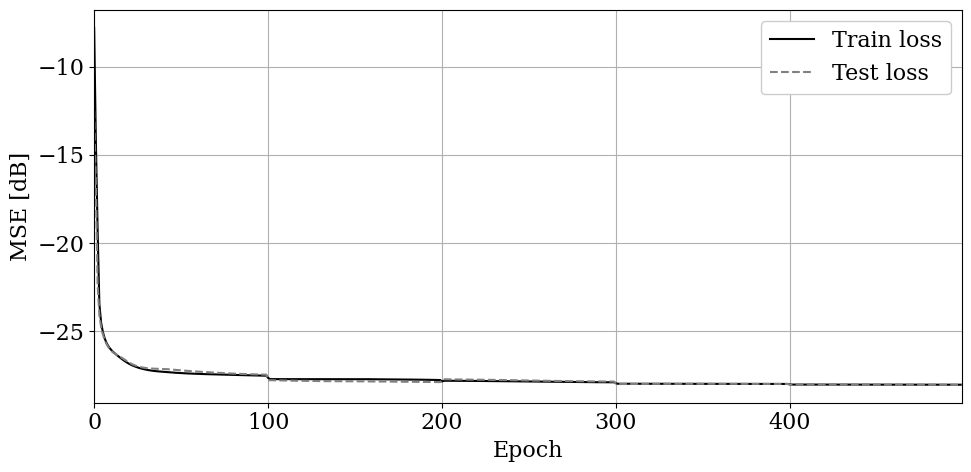

In [20]:
fig, axs = plt.subplots(figsize = (10, 5))
axs.plot(10*np.log10(trainLoss), color = "k", label = "Train loss")
axs.plot(10*np.log10(testLoss), "--", color = "gray", label = "Test loss")

axs.set_xlim(0, paramRoF.epochs - 1)
axs.set_ylabel("MSE [dB]")
axs.set_xlabel("Epoch")
axs.grid()
axs.legend(fontsize = 16, framealpha = 1)
plt.tight_layout()

In [21]:
sig_nn = fitFilterNN(sigRef, RoFChannel_model, paramRoF.Ntaps, paramRoF.K, 1, 100, augment = paramRoF.augment, prgsBar = True)

100%|████████████████████████████████████████████████████████████████████████████| 1788/1788 [00:00<00:00, 2634.22it/s]


MSE = -24.649 dB


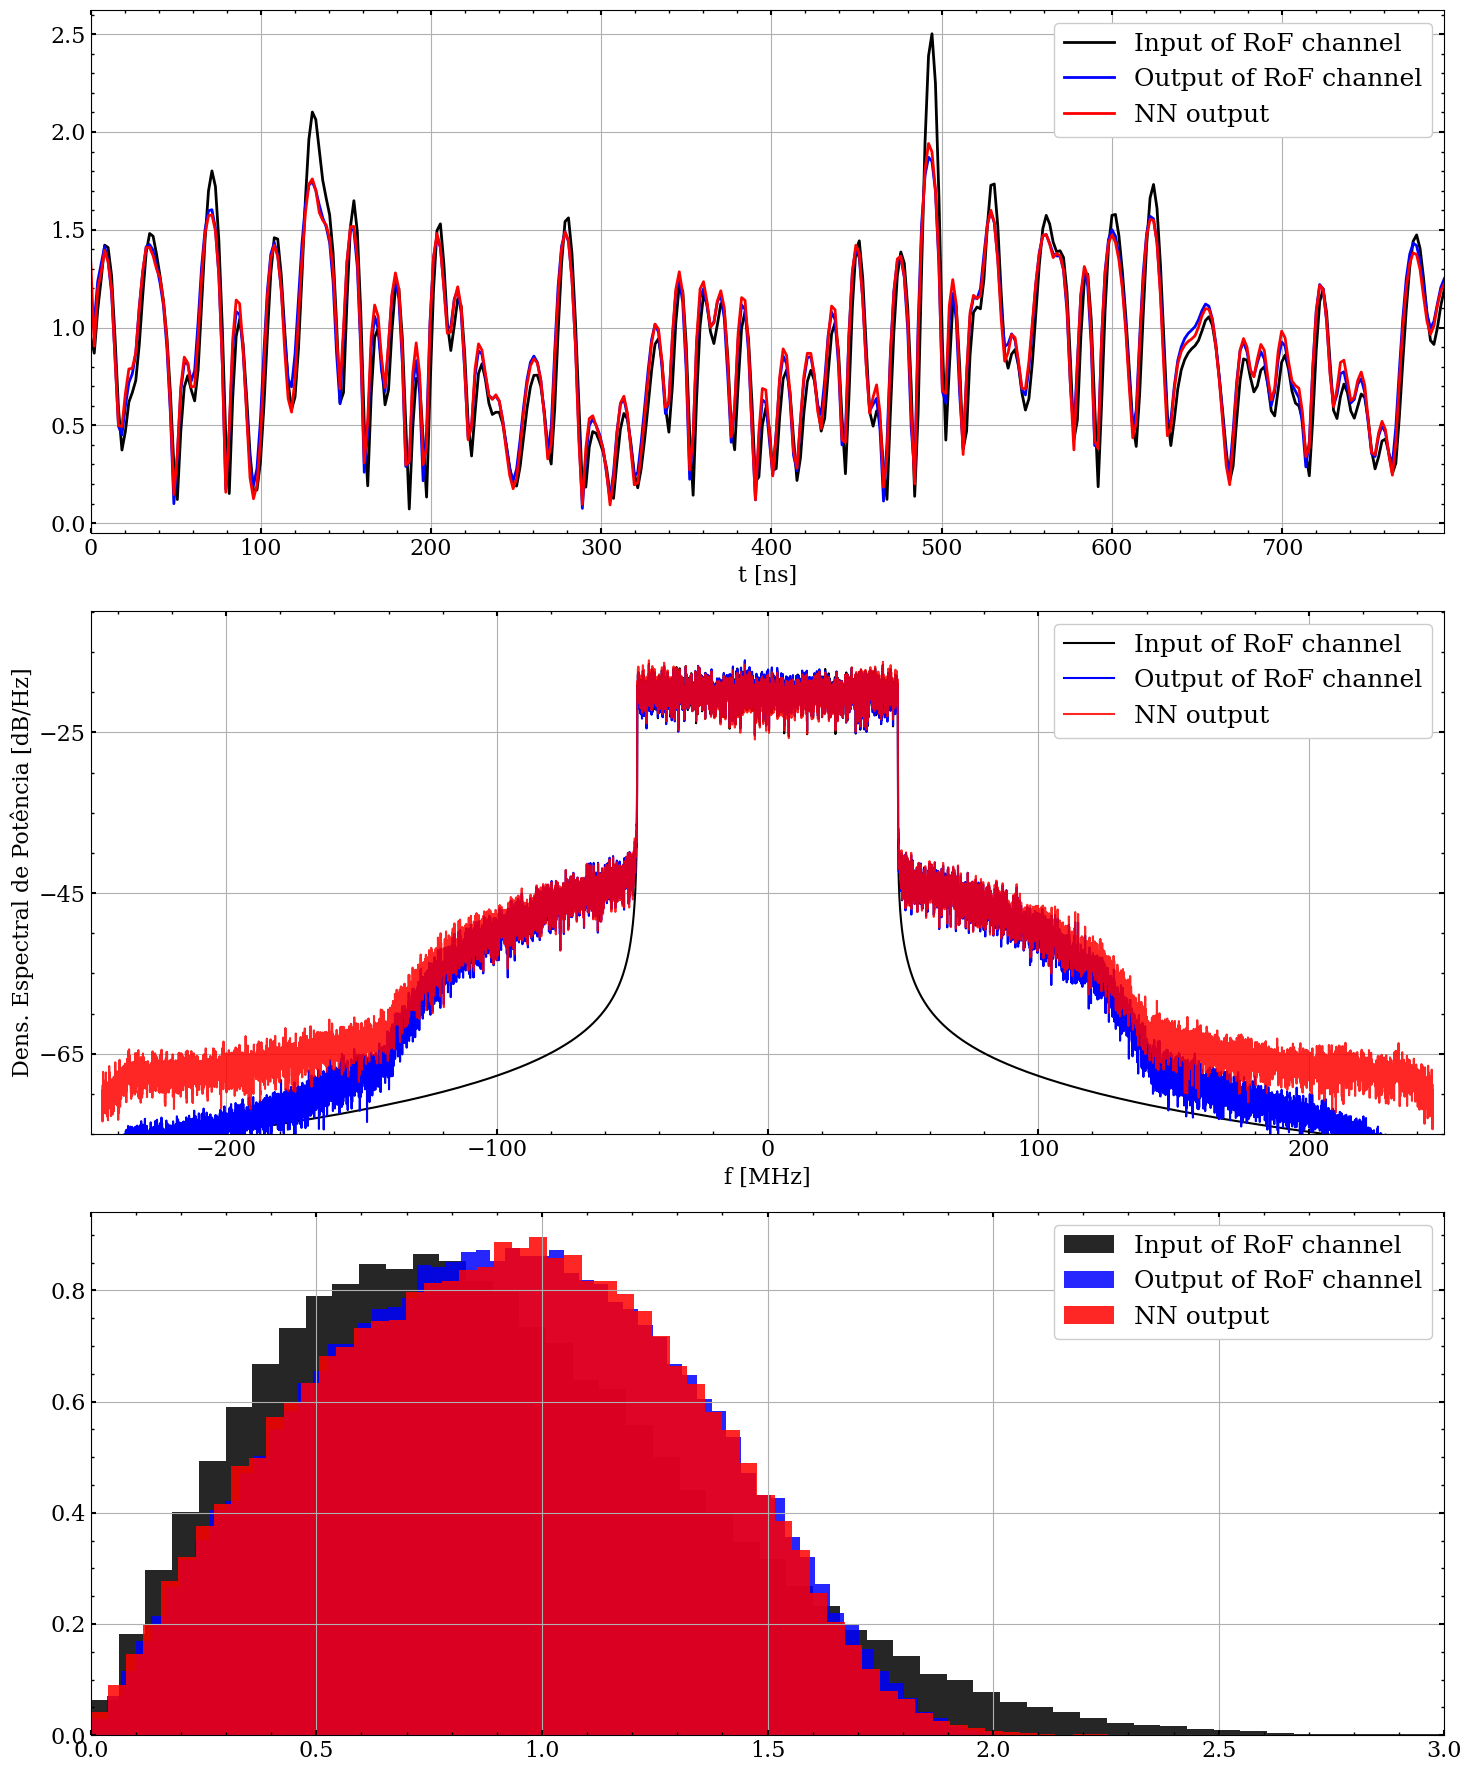

In [26]:
indx = np.arange(0, int(10000*SpS_DPD/SpS))
fig, axs = plt.subplots(3, 1, figsize = (15, 18))
t = np.arange(0, len(sigRef))*(1/Fs)*(SpS/SpS_DPD)

MSE = 10*th.log10(th.mean(th.abs(sigIn - sig_nn)**2))
print(f"MSE = {MSE:.3f} dB")

axs[0].plot(t[indx]*1e9, np.abs(sigRef.detach().cpu().numpy()[indx]), "k", lw = 2, label = "Input of RoF channel")
axs[0].plot(t[indx]*1e9, np.abs(sigIn.detach().cpu().numpy()[indx]),  "b", lw = 2, label = "Output of RoF channel")
axs[0].plot(t[indx]*1e9, np.abs(sig_nn.detach().cpu().numpy()[indx]), "r", lw = 2, label = "NN output")

axs[0].set_xlim(0, np.max(t[indx])*1e9)
axs[0].legend(framealpha = 1, fontsize = 18, loc = "upper right")
axs[0].set_xlabel("t [ns]")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].psd(sigRef.detach().cpu().numpy(), Fs = (SpS_DPD/SpS)*Fs/1e6, NFFT = 16*1024, sides = 'twosided', color = "k", label = "Input of RoF channel")
axs[1].psd(sigIn.detach().cpu().numpy(), Fs = (SpS_DPD/SpS)*Fs/1e6, NFFT = 16*1024, sides = 'twosided', color = "b", label = "Output of RoF channel")
axs[1].psd(sig_nn.detach().cpu().numpy(), Fs = (SpS_DPD/SpS)*Fs/1e6, NFFT = 16*1024, sides = 'twosided', color = "r", label = "NN output", alpha = 0.85)
axs[1].set_xlabel("f [MHz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-250, 250)
axs[1].set_ylim(-75)
axs[1].grid(True)
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[1].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[2].hist(np.abs(sigRef.detach().cpu().numpy()), density = True, bins = 64, color = "k", label = 'Input of RoF channel', alpha = 0.85)
axs[2].hist(np.abs(sigIn.detach().cpu().numpy()), density = True, bins = 64, color = "b", label = 'Output of RoF channel', alpha = 0.85)
axs[2].hist(np.abs(sig_nn.detach().cpu().numpy()), density = True, bins = 64, color = "r", label = 'NN output', alpha = 0.85)
axs[2].set_xlim(0, 3)
axs[2].grid()
axs[2].minorticks_on()
axs[2].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[2].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[2].legend(framealpha = 1, fontsize = 18, loc = "upper right")

plt.tight_layout()
plt.show()

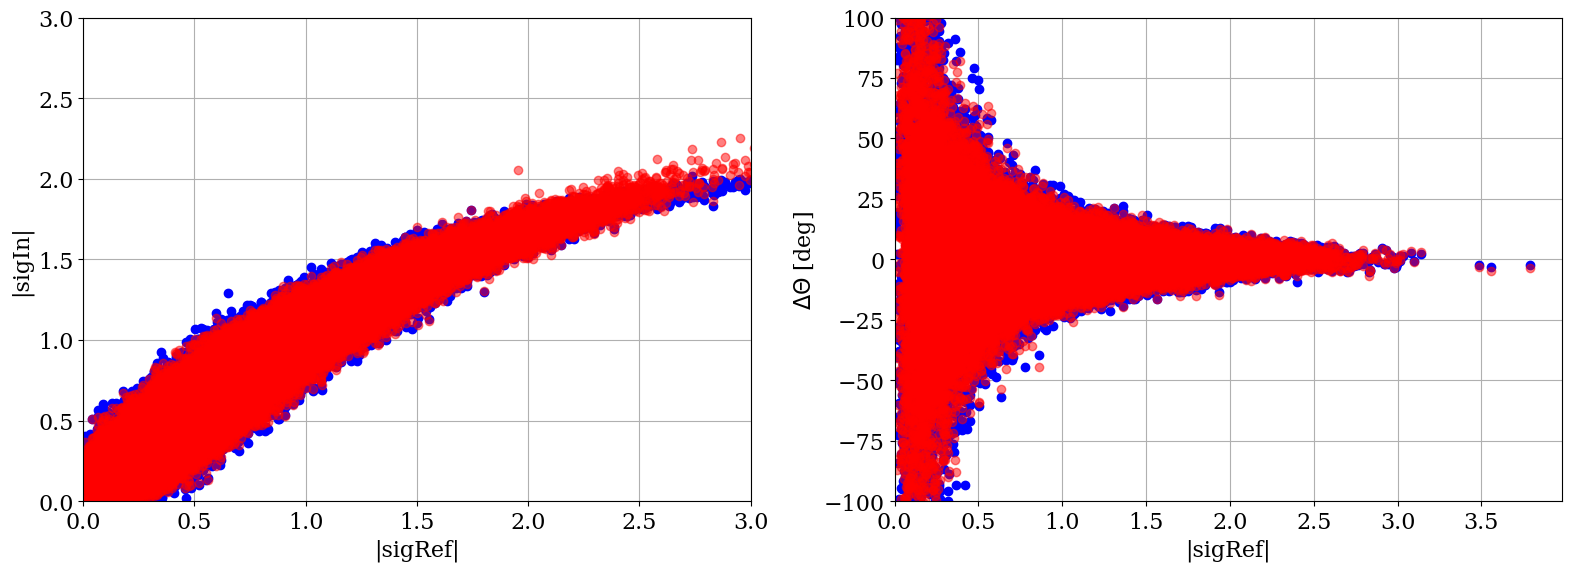

In [27]:
fig, axs = plt.subplots(1, 2, figsize = (16, 6))

n_pts = 100_000

axs[0].plot(np.abs(sigRef.detach().cpu().numpy()[0:n_pts]), np.abs(sigIn.detach().cpu().numpy()[0:n_pts]), "o", color = "b")
axs[0].plot(np.abs(sigRef.detach().cpu().numpy()[0:n_pts]), np.abs(sig_nn.detach().cpu().numpy()[0:n_pts]), "o", color = "r", alpha = 0.5)
axs[0].set_xlim(0,3)
axs[0].set_ylim(0,3)
axs[0].set_xlabel("|sigRef|")
axs[0].set_ylabel("|sigIn|")
axs[0].grid()

axs[1].plot(np.abs(sigRef.detach().cpu().numpy()[0:n_pts]), (np.angle(sigIn.detach().cpu().numpy()) - np.angle(sigRef.detach().cpu().numpy()))[0:n_pts]*180/pi, "o", color = "b")
axs[1].plot(np.abs(sigRef.detach().cpu().numpy()[0:n_pts]), (np.angle(sig_nn.detach().cpu().numpy()) - np.angle(sigRef.detach().cpu().numpy()))[0:n_pts]*180/pi, "o", color = "r", alpha = 0.5)
axs[1].set_xlim(0)
axs[1].set_ylim(-100, 100)
axs[1].set_xlabel("|sigRef|")
axs[1].set_ylabel("$\Delta \Theta$ [deg]")
axs[1].grid()

plt.tight_layout()

### 3 - Arquitetura de Aprendizado Indireto (ILA)

In [66]:
paramDPD = parameters()

N = 100_000

paramDPD.divByL = 1
paramDPD.trainTestFrac = 0.75
paramDPD.batch_size = 1_000
paramDPD.shuffle = False
paramDPD.includeMemory = True
paramDPD.Ntaps = 4
paramDPD.K = 2
paramDPD.augment = True

paramDPD.layers = [(paramDPD.K + 2)*paramDPD.Ntaps, 50, 2]

paramDPD.device = device
paramDPD.lr = 5e-3
paramDPD.epochs = 500
paramDPD.activation = "relu"
paramDPD.pgrsBar = True
paramDPD.directLearn = False

paramDPD.envelope = False

DPD, trainLoss, testLoss = NN_training(sigIn[0:N], sigRef[0:N], paramDPD)

  0%|          | 0/500 [00:00<?, ?it/s]

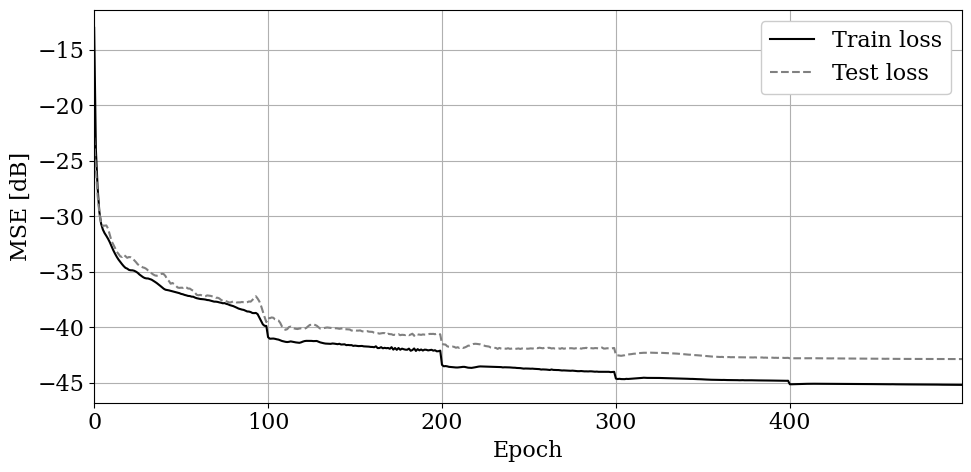

In [67]:
fig, axs = plt.subplots(figsize = (10, 5))
axs.plot(10*np.log10(trainLoss), color = "k", label = "Train loss")
axs.plot(10*np.log10(testLoss), "--", color = "gray", label = "Test loss")

axs.set_xlim(0, paramDPD.epochs - 1)
axs.set_ylabel("MSE [dB]")
axs.set_xlabel("Epoch")
axs.grid()
axs.legend(fontsize = 16, framealpha = 1)
plt.tight_layout()

In [68]:
sig_nn = fitFilterNN(sigIn, DPD, paramDPD.Ntaps, paramDPD.K, 1, 100, augment = paramDPD.augment, prgsBar = True)

100%|████████████████████████████████████████████████████████████████████████████| 1788/1788 [00:00<00:00, 2574.62it/s]


MSE = -34.908 dB


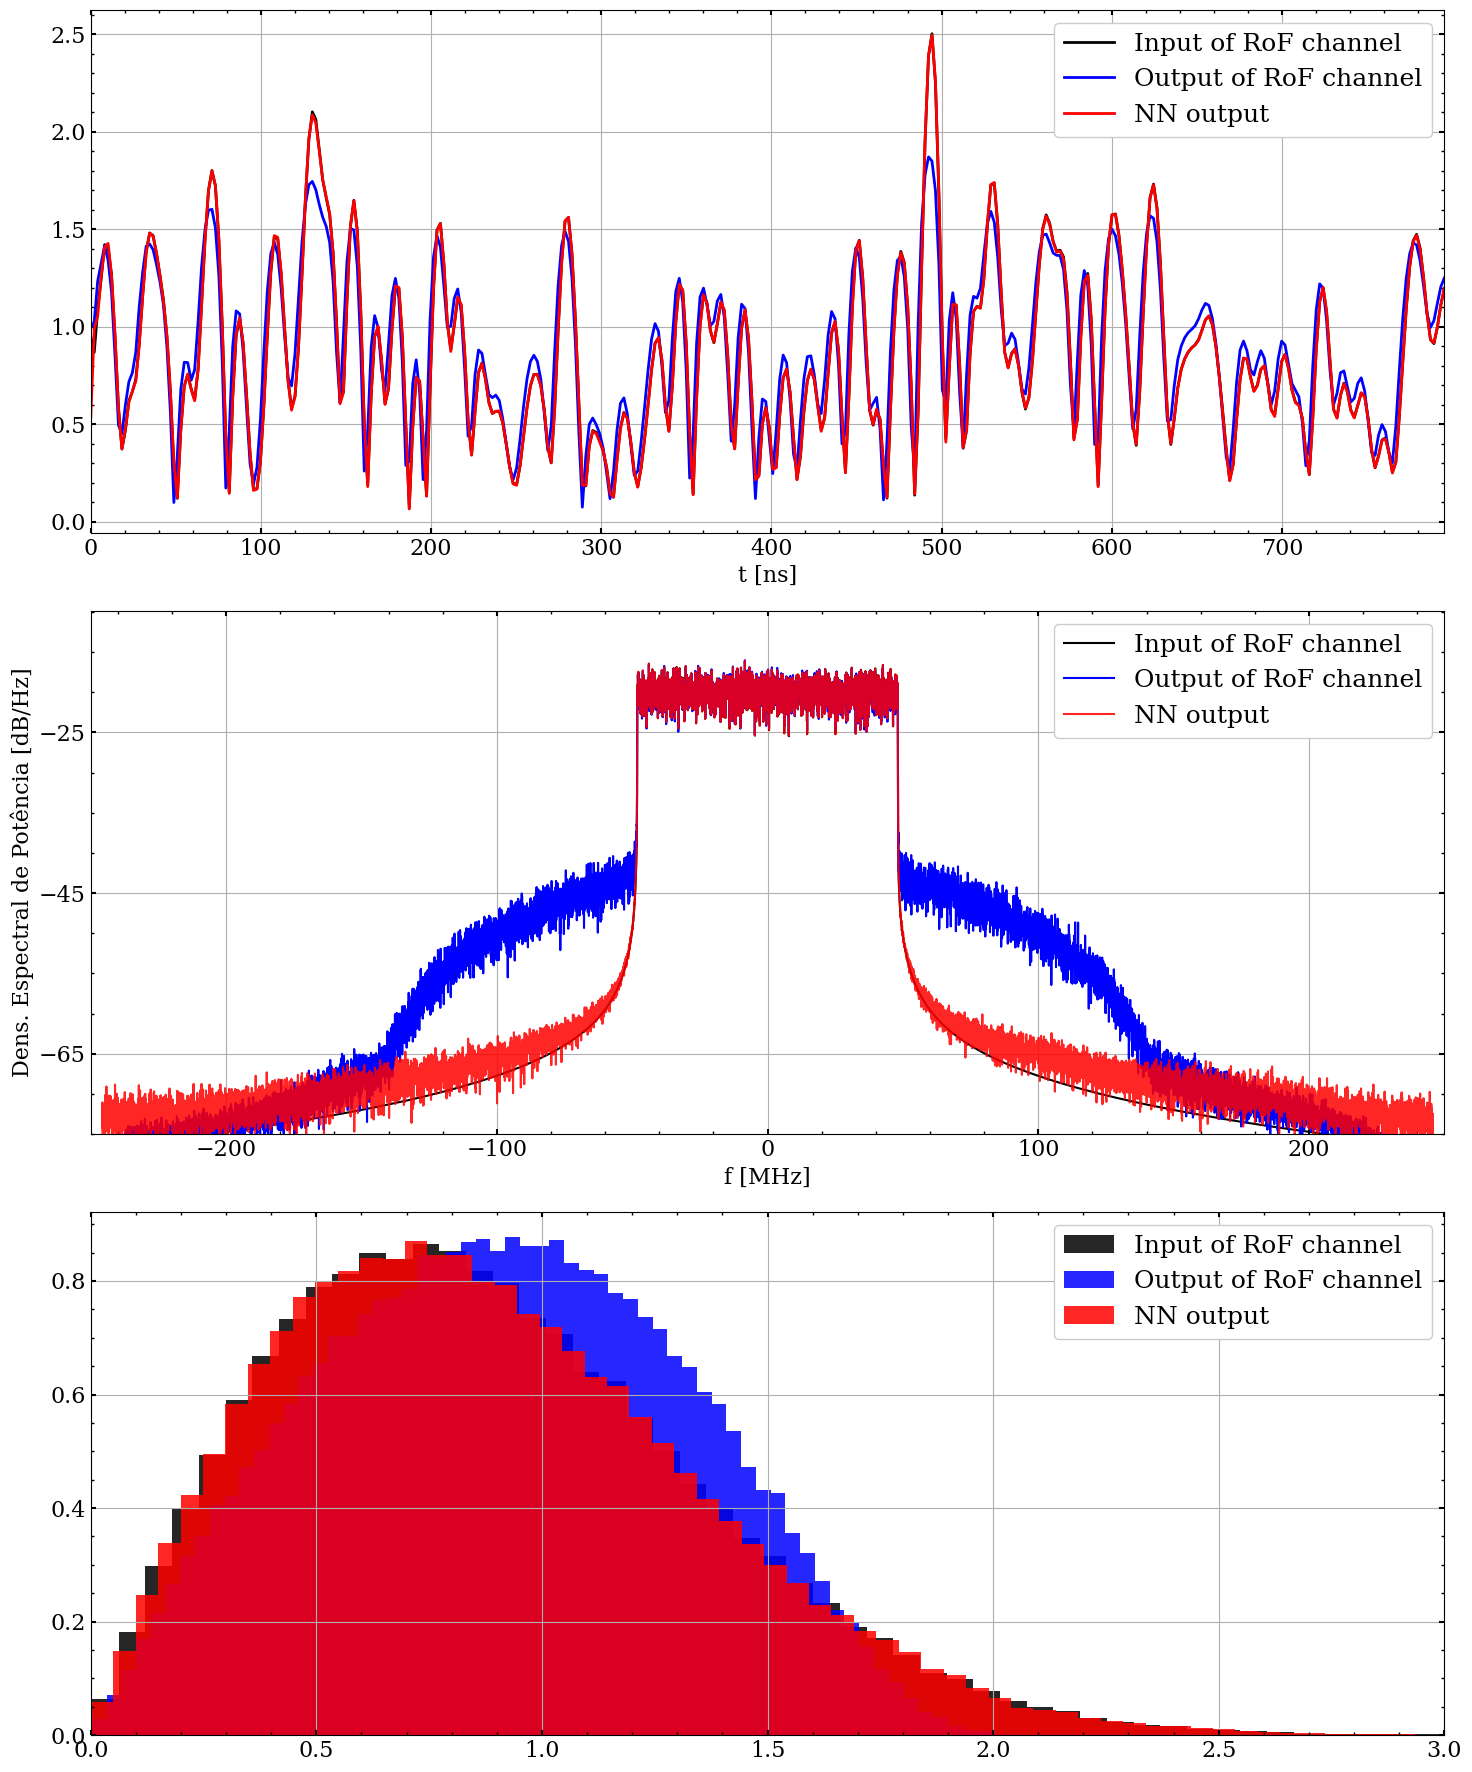

In [69]:
indx = np.arange(0, int(10000*SpS_DPD/SpS))
fig, axs = plt.subplots(3, 1, figsize = (15, 18))
t = np.arange(0, len(sigRef))*(1/Fs)*(SpS/SpS_DPD)

MSE = 10*th.log10(th.mean(th.abs(sigRef - sig_nn)**2))
print(f"MSE = {MSE:.3f} dB")

axs[0].plot(t[indx]*1e9, np.abs(sigRef.detach().cpu().numpy()[indx]), "k", lw = 2, label = "Input of RoF channel")
axs[0].plot(t[indx]*1e9, np.abs(sigIn.detach().cpu().numpy()[indx]),  "b", lw = 2, label = "Output of RoF channel")
axs[0].plot(t[indx]*1e9, np.abs(sig_nn.detach().cpu().numpy()[indx]), "r", lw = 2, label = "NN output")

axs[0].set_xlim(0, np.max(t[indx])*1e9)
axs[0].legend(framealpha = 1, fontsize = 18, loc = "upper right")
axs[0].set_xlabel("t [ns]")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].psd(sigRef.detach().cpu().numpy(), Fs = (SpS_DPD/SpS)*Fs/1e6, NFFT = 16*1024, sides = 'twosided', color = "k", label = "Input of RoF channel")
axs[1].psd(sigIn.detach().cpu().numpy(), Fs = (SpS_DPD/SpS)*Fs/1e6, NFFT = 16*1024, sides = 'twosided', color = "b", label = "Output of RoF channel")
axs[1].psd(sig_nn.detach().cpu().numpy(), Fs = (SpS_DPD/SpS)*Fs/1e6, NFFT = 16*1024, sides = 'twosided', color = "r", label = "NN output", alpha = 0.85)
axs[1].set_xlabel("f [MHz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-250, 250)
axs[1].set_ylim(-75)
axs[1].grid(True)
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[1].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[2].hist(np.abs(sigRef.detach().cpu().numpy()), density = True, bins = 64, color = "k", label = 'Input of RoF channel', alpha = 0.85)
axs[2].hist(np.abs(sigIn.detach().cpu().numpy()), density = True, bins = 64, color = "b", label = 'Output of RoF channel', alpha = 0.85)
axs[2].hist(np.abs(sig_nn.detach().cpu().numpy()), density = True, bins = 64, color = "r", label = 'NN output', alpha = 0.85)
axs[2].set_xlim(0, 3)
axs[2].grid()
axs[2].minorticks_on()
axs[2].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[2].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[2].legend(framealpha = 1, fontsize = 18, loc = "upper right")

plt.tight_layout()
plt.show()

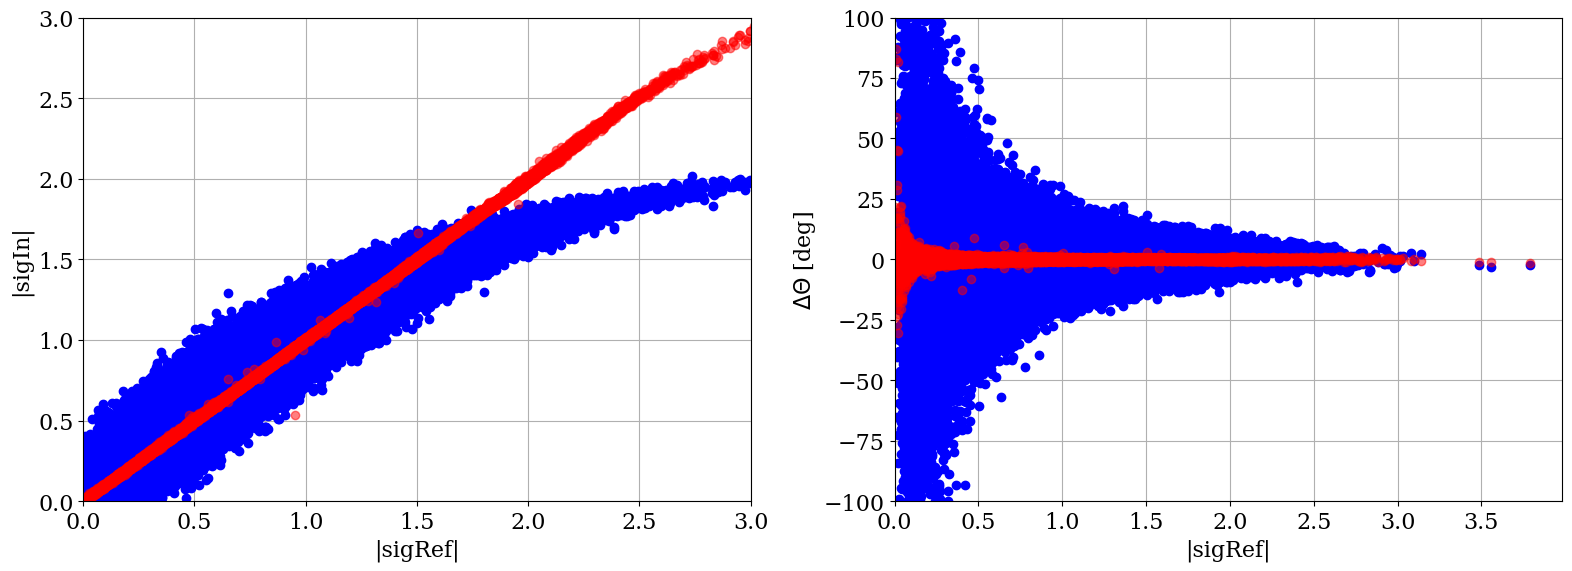

In [70]:
fig, axs = plt.subplots(1, 2, figsize = (16, 6))

n_pts = 100_000

axs[0].plot(np.abs(sigRef.detach().cpu().numpy()[0:n_pts]), np.abs(sigIn.detach().cpu().numpy()[0:n_pts]), "o", color = "b")
axs[0].plot(np.abs(sigRef.detach().cpu().numpy()[0:n_pts]), np.abs(sig_nn.detach().cpu().numpy()[0:n_pts]), "o", color = "r", alpha = 0.5)
axs[0].set_xlim(0,3)
axs[0].set_ylim(0,3)
axs[0].set_xlabel("|sigRef|")
axs[0].set_ylabel("|sigIn|")
axs[0].grid()

axs[1].plot(np.abs(sigRef.detach().cpu().numpy()[0:n_pts]), (np.angle(sigIn.detach().cpu().numpy()) - np.angle(sigRef.detach().cpu().numpy()))[0:n_pts]*180/pi, "o", color = "b")
axs[1].plot(np.abs(sigRef.detach().cpu().numpy()[0:n_pts]), (np.angle(sig_nn.detach().cpu().numpy()) - np.angle(sigRef.detach().cpu().numpy()))[0:n_pts]*180/pi, "o", color = "r", alpha = 0.5)
axs[1].set_xlim(0)
axs[1].set_ylim(-100, 100)
axs[1].set_xlabel("|sigRef|")
axs[1].set_ylabel("$\Delta \Theta$ [deg]")
axs[1].grid()

plt.tight_layout()


### 5 - DPD Test

In [71]:
paramOFDM.SpS = SpS_DPD

sigTx = modulateOFDM(symbTx, paramOFDM)
sigTx = pnorm(sigTx)

# ILA
DPD.eval()
sigTx_DPD = fitFilterNN(th.from_numpy(sigTx.copy()).to(device).type(th.complex64), DPD, paramDPD.Ntaps, paramDPD.K, 1, 100, augment = paramDPD.augment)
sigTx_DPD = sigTx_DPD.detach().cpu().numpy()

gain_DPD  = np.sqrt(signal_power(sigTx_DPD))

In [72]:
numtaps = 4096
h_dpd = firwin(numtaps, 2*Rs, fs = Fs)

sigTx_DPD = clockSamplingInterp(sigTx_DPD.reshape(-1, 1), Fs*SpS_DPD/SpS, Fs).ravel()
sigTx_DPD = firFilter(h_dpd, sigTx_DPD)
sigTx_DPD = pnorm(sigTx_DPD)

t = np.arange(0, sigTx_DPD.size)*1/Fs
t_CP   = SpS * paramOFDM.G * (1/Fs)
t_symb = SpS * (paramOFDM.Nfft + paramOFDM.G) * (1/Fs)

#### 6.1 Sinal RF

In [73]:
sigTx_RF = np.real( sigTx_DPD * gain_DPD * np.exp(1j*2*pi*paramRF.fc_e*t) )
sigTx_RF *= gain_pre_MZM
sigTx_RF = np.clip(sigTx_RF, -paramMZM.Vpi/2, paramMZM.Vpi/2)

print(f"Power at MZM's input with DPD: {10*np.log10(1e3*signal_power(sigTx_RF)):.3f} dBm")

Power at MZM's input with DPD: 17.674 dBm


#### 6.2 Sinal óptico

In [74]:
Ai     = np.sqrt(dBm2W(paramMZM.Pin_OF))*np.ones(sigTx_RF.size)
sigTxo = mzm(Ai, sigTx_RF, paramMZM)

numtaps = 4096
hopt_tx = firwin(numtaps, paramRF.fc_e + 2*Rs, fs = Fs)
sigTxo  = np.sqrt(signal_power(sigTxo))*pnorm(firFilter(hopt_tx, sigTxo))

sigRxo = linearFiberChannel(sigTxo, paramChannel)

print(f"P_Txo = {10*np.log10(signal_power(sigTxo)*1e3):.3f} dBm")
print(f"P_Rxo = {10*np.log10(signal_power(sigRxo)*1e3):.3f} dBm")

P_Txo = 6.990 dBm
P_Rxo = 1.990 dBm


#### 6.3 Sinal elétrico (fotocorrente)

In [75]:
I_Rx  = photodiode(sigRxo, paramPD)
I_Rx -= I_Rx.mean()

#### 6.4 Sinal elétrico pós-FPF

In [76]:
# Filtro passa-faixas
numtaps = 4096
f1 = paramRF.fc_e - 2*Rs
f2 = paramRF.fc_e + 2*Rs
hbp_RF = firwin(numtaps, (f1, f2), pass_zero = 'bandpass', fs = Fs)

I_RF = firFilter(hbp_RF, I_Rx)

#### 6.5 Sinal elétrico pós-PA

In [77]:
sigRx = hilbert(I_RF)*np.exp(-1j*2*pi*paramRF.fc_e*t)
sigRx *= gain_pre_PA

print(f"Power at PA's input: {10*np.log10(1e3*signal_power(sigRx)):.3f} dBm")

sigRx = power_amplifier(sigRx)
sigRx_PA_DPD = sigRx.copy()
sigRx_PA_DPD = pnorm(sigRx_PA_DPD)

numtaps = 4096
hlp   = firwin(numtaps, Rs/1.75, fs = Fs)
sigRx = firFilter(hlp, sigRx)

delay = finddelay(sigRx, sigTx_DPD)
sigRx = np.roll(sigRx, -delay)

rot   = np.mean(sigTx_DPD/sigRx)
sigRx = rot/np.abs(rot)*sigRx

Power at PA's input: 5.483 dBm


#### Perfomance

In [78]:
# Parâmetros da decimação
paramDec = parameters()
paramDec.SpS_in  = SpS
paramDec.SpS_out = 1
samples_per_frame = SpS * (paramOFDM.Nfft + paramOFDM.G)

symbRx_OFDM = sigRx.copy()[0::SpS][0:paramOFDM.numOFDMframes*(paramOFDM.Nfft + paramOFDM.G)]
symbRx_DPD  = demodulateOFDM(symbRx_OFDM, paramOFDM)

BER = 0.00000 
SNR = 29.141 dB 
EVM = 3.492 %


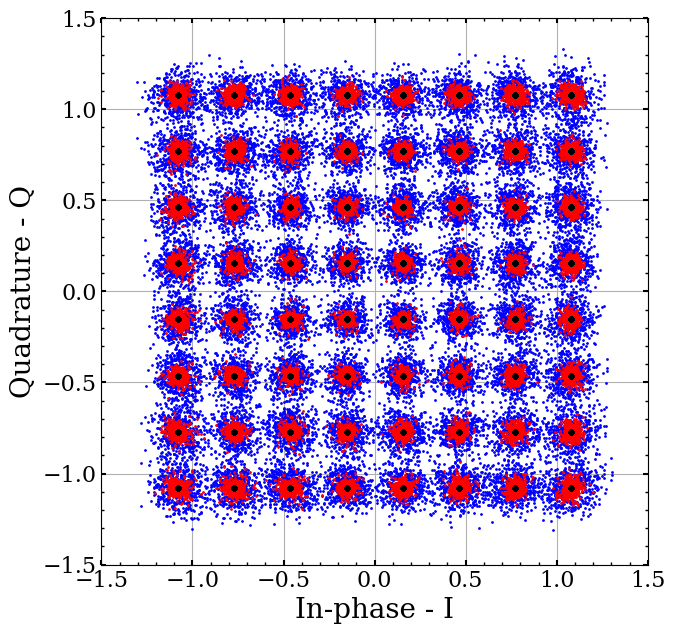

In [79]:
discard = 100
index = np.arange(0, symbTx.size - discard)
BER, _, SNR = fastBERcalc(symbRx_DPD[index], symbTx[index], paramOFDM.modOrder, paramOFDM.modType)

EVM = np.sqrt(calcEVM(symbRx_DPD[index], paramOFDM.modOrder, paramOFDM.modType, symbTx[index]))*100

print(f"BER = {BER[0]:.5f} \nSNR = {SNR[0]:.3f} dB \nEVM = {EVM[0]:.3f} %")

# Normalização para o plot
symbTx = pnorm(symbTx)
symbRx_DPD = pnorm(symbRx_DPD)

fig, axs = plt.subplots(figsize = (7, 7))
axs.plot(symbRx[index].real, symbRx[index].imag, "o", color = "b", ms = 1)
axs.plot(symbRx_DPD[index].real, symbRx_DPD[index].imag, "o", color = "r", ms = 1)
axs.plot(symbTx.real, symbTx.imag, "o", color = "k", ms = 3)
axs.set_ylabel("Quadrature - Q", fontsize = 20)
axs.set_xlabel("In-phase - I", fontsize = 20)
plt.axis("square")

axs.set_xlim(-1.5, 1.5)
axs.set_ylim(-1.5, 1.5)
axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

plt.grid()
plt.tight_layout()
#plt.savefig("constelacao_nnDPD.png")

In [80]:
freq, P_sigTx        = welch(pnorm(sigTx), fs = SpS_DPD*Rs, nfft = 16*1024, return_onesided = False)
freq, P_sigRx_PA     = welch(pnorm(sigRx_PA)[0::SpS//SpS_DPD], fs = SpS_DPD*Rs, nfft = 16*1024, return_onesided = False)
freq, P_sigRx_PA_DPD = welch(pnorm(sigRx_PA_DPD)[0::SpS//SpS_DPD], fs = SpS_DPD*Rs, nfft = 16*1024, return_onesided = False)

SigTx - ACLR = -42.932 dB
SigRx PA w/o DPD - ACLR = -28.263 dB
SigRx PA w DPD - ACLR = -35.851 dB


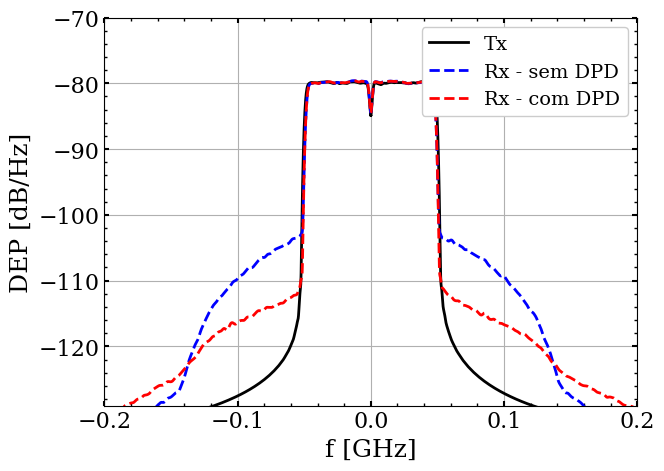

In [81]:
print(f"SigTx - ACLR = {calcACLR(P_sigTx, freq, paramOFDM.bw/2, 2.5e6):.3f} dB")
print(f"SigRx PA w/o DPD - ACLR = {calcACLR(P_sigRx_PA, freq, paramOFDM.bw/2, 2.5e6):.3f} dB")
print(f"SigRx PA w DPD - ACLR = {calcACLR(P_sigRx_PA_DPD, freq, paramOFDM.bw/2, 2.5e6):.3f} dB")

fig, axs = plt.subplots(1, 1, figsize = (7, 5))

axs.plot(freq/1e9, 10*np.log10(P_sigTx), lw = 2, color = "k", label = "Tx")
axs.plot(freq/1e9, 10*np.log10(P_sigRx_PA), lw = 2, color = "b", label = "Rx - sem DPD", ls = "--")
axs.plot(freq/1e9, 10*np.log10(P_sigRx_PA_DPD), lw = 2, color = "r", label = "Rx - com DPD", ls = "--")

axs.set_xlim(-0.2, 0.2)
axs.set_ylim(-129, -70)

axs.set_ylabel("DEP [dB/Hz]", fontsize = 18)
axs.set_xlabel("f [GHz]", fontsize = 18)
axs.legend(framealpha = 1, fontsize = 14, loc = "upper right")

axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs.grid()

plt.tight_layout()
#plt.savefig("sig_freq_mpDPD.pdf")